# Support Vector Machines (SVM)

**Francisco Aparecido Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Nesta aula vamos construir a intuição por trás do **SVM (Support Vector Machine)** e depois aplicar o método a dois conjuntos de dados reais.

Imagine que você tem pontos de duas classes (por exemplo, ● e ▲) em um plano, e quer traçar uma reta que separe as duas classes. Se os dados forem linearmente separáveis, existem **infinitas retas** capazes de separar as classes perfeitamente. A pergunta do SVM é: **qual dessas retas é a melhor escolha?**

O SVM escole a reta que fica **o mais longe possível dos pontos mais próximos de cada classe**. Pense nisso como encontrar a rua mais larga possível que passa entre as duas classes, sem atropelar nenhum ponto, e depois traçar a fronteira de decisão bem no meio dessa rua. Essa "largura da rua" é chamada de **margem**, e os pontos que tocam as bordas dessa rua (os que estão mais próximos da fronteira) são chamados de **vetores de suporte**. São eles que determinam a fronteira de decisão. Todos os demais pontos, mais distantes, poderiam ser removidos do conjunto de treinamento sem mudar a fronteira encontrada.

Intuitivamente, uma fronteira "apertada" entre as classes tem pouca margem de erro, isto é, um pequeno deslocamento em um novo dado (ruído, erro de medição) pode fazer com que ele caia do lado errado. Uma fronteira bem no meio de uma margem larga é mais **robusta** a esse tipo de variação e, historicamente, essa robustez se traduz em melhor capacidade de generalização para dados novos.

<p align="center">
    <img src="https://www.iunera.com/wp-content/uploads/image-16.png?v=1596613714" width="400" />
</p>

Matematicamente, uma fronteira linear pode ser escrita como $\mathbf{w}^\top \mathbf{x} + b = 0$. A distância entre as duas bordas da margem é $\dfrac{2}{\lVert \mathbf{w} \rVert}$. Maximizar essa margem é equivalente a **minimizar** $\lVert \mathbf{w} \rVert$ (ou, por conveniência matemática, $\tfrac{1}{2}\lVert \mathbf{w} \rVert^2$), sujeito à restrição de que todo ponto esteja do lado correto da margem:

$$\min_{\mathbf{w}, b} \ \frac{1}{2} \lVert \mathbf{w} \rVert^2 \quad \text{sujeito a} \quad y_i (\mathbf{w}^\top \mathbf{x}_i + b) \geq 1, \ \forall i$$

em que $y_i \in \{-1, +1\}$ é o rótulo da classe do ponto $i$. Ou seja, a ideia é **minimizar $\lVert \mathbf{w} \rVert$ é a mesma coisa que maximizar a largura da rua**, e a **restrição** garante que ninguém fique do lado errado dela.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/72/SVM_margin.png/960px-SVM_margin.png" width=300 />

## Exemplo: dados perfeitamente separáveis

Vamos criar um pequeno conjunto de dados bidimensional, perfeitamente separável por uma reta, e ajustar um SVM linear com um valor elevado de $C$. Nesse regime, a regularização é muito fraca e o modelo se aproxima de um SVM de margem rígida, penalizando fortemente qualquer erro de classificação.

Vamos criar uma função para graficar os dados.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC

np.random.seed(42)

def plot_svm(modelo, X, y, ax=None, titulo="", mostrar_margem=True, 
             mostrar_vetores_suporte=True):
    """Função auxiliar: desenha os pontos, a fronteira de decisão, a margem e os vetores de suporte de um SVM 2D."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=40, zorder=3)

    xlim = ax.get_xlim() if ax.get_xlim() != (0.0, 1.0) else (X[:, 0].min() - 1, X[:, 0].max() + 1)
    ylim = ax.get_ylim() if ax.get_ylim() != (0.0, 1.0) else (X[:, 1].min() - 1, X[:, 1].max() + 1)

    xx = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    yy = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
    YY, XX = np.meshgrid(yy, xx)
    grid = np.c_[XX.ravel(), YY.ravel()]
    Z = modelo.decision_function(grid).reshape(XX.shape)

    if mostrar_margem:
        ax.contour(XX, YY, Z, colors="k", levels=[-1, 0, 1], alpha=0.7,
                   linestyles=["--", "-", "--"], linewidths=[1.2, 2, 1.2])
    else:
        ax.contour(XX, YY, Z, colors="k", levels=[0], linewidths=2)

    if mostrar_vetores_suporte and hasattr(modelo, "support_vectors_"):
        ax.scatter(modelo.support_vectors_[:, 0], modelo.support_vectors_[:, 1],
                   s=180, facecolors="none", edgecolors="black", linewidths=1.5, zorder=4,
                   label="Vetores de suporte")
        ax.legend(loc="best")

    ax.set_title(titulo)
    ax.set_xlabel("Atributo 1")
    ax.set_ylabel("Atributo 2")
    return ax

Criando o conjunto de dados e fazendo a classificação.

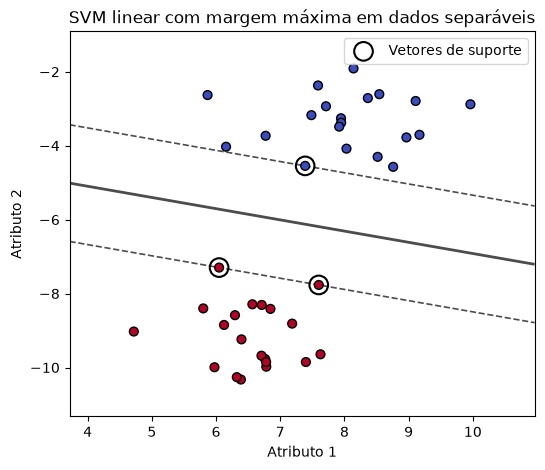

Número de vetores de suporte: 3 (de 40 pontos no total)


In [38]:
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Cria uma base de dados bidimensional com duas classes.
# O parâmetro cluster_std controla a dispersão dos grupos.
# Com os valores escolhidos, as classes ficam linearmente separáveis.
X_sep, y_sep = make_blobs(
    n_samples=40,
    centers=2,
    cluster_std=0.8,
    random_state=6
)

# Ajusta um SVM linear com valor muito alto de C.
# Nesse caso, erros de classificação são fortemente penalizados, fazendo com que o modelo se aproxime de um SVM de margem rígida.
modelo_svm_separavel = SVC(
    kernel="linear", # Usa o kernel linear
    C = 10 # Valor alto de C para penalizar erros de classificação
)
# Reliza o ajuste aos dados
modelo_svm_separavel.fit(X_sep, y_sep)

# Exibe a fronteira de decisão, as margens e os vetores de suporte.
plot_svm(
    modelo_svm_separavel,
    X_sep,
    y_sep,
    titulo="SVM linear com margem máxima em dados separáveis"
)
plt.show()

# Os vetores de suporte são os pontos mais próximos da fronteira de decisão.
# Eles determinam a posição da reta separadora e a largura da margem.
numero_vetores_suporte = len(modelo_svm_separavel.support_vectors_)
print(
    f"Número de vetores de suporte: {numero_vetores_suporte} "
    f"(de {len(X_sep)} pontos no total)"
)

Note como a fronteira (linha cheia) fica exatamente no meio das duas linhas tracejadas (as bordas da margem) e como apenas alguns pontos, os **vetores de suporte**, marcados com círculos, tocam essas bordas. Se removêssemos qualquer outro ponto do conjunto de treinamento (um ponto "bem no meio" de sua classe), a fronteira encontrada seria exatamente a mesma.

## Margem suave e o hiperparâmetro de regularização $C$

Dados reais raramente são perfeitamente separáveis. Em geral, existe algum grau de sobreposição entre as classes, provocado por ruído, erros de medição, observações atípicas ou pela própria natureza do problema. Nesses casos, exigir uma separação perfeita por meio de uma margem rígida pode tornar o problema inviável ou produzir uma fronteira de decisão excessivamente sensível a poucos pontos. Para lidar com essa situação, o SVM utiliza a margem flexível, permitindo algumas violações da margem ou até erros de classificação em troca de uma solução mais estável e com melhor capacidade de generalização.

A solução é permitir que alguns pontos **violem a margem** (ou até fiquem do lado errado da fronteira), mas **penalizando** essas violações. Introduzimos variáveis de folga $\xi_i \geq 0$ (uma por ponto), que medem o quanto cada ponto viola a margem, e reformulamos o problema:

$$\min_{\mathbf{w}, b, \xi} \ \frac{1}{2}\lVert \mathbf{w} \rVert^2 + C \sum_i \xi_i \quad \text{sujeito a} \quad y_i (\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i, \ \xi_i \geq 0$$

O hiperparâmetro $C > 0$ controla o **trade-off entre margem larga e poucas violações**:
- **$C$ grande**: violar a margem é caro, então o modelo prioriza classificar cada ponto de treino corretamente, mesmo que isso signifique uma margem estreita e uma fronteira mais "tortuosa", com maior risco de **sobreajuste** (*overfitting*);
- **$C$ pequeno**: violar a margem é barato, então o modelo prioriza uma margem larga e suave, tolerando mais erros de classificação no treino, com maior risco de **subajuste** (*underfitting*) se $C$ for baixo demais.

$C$ é, portanto, o principal **hiperparâmetro de regularização** do SVM: quanto **menor** o $C$, mais forte a regularização (fronteira mais simples, mais tolerante a erros no treino).

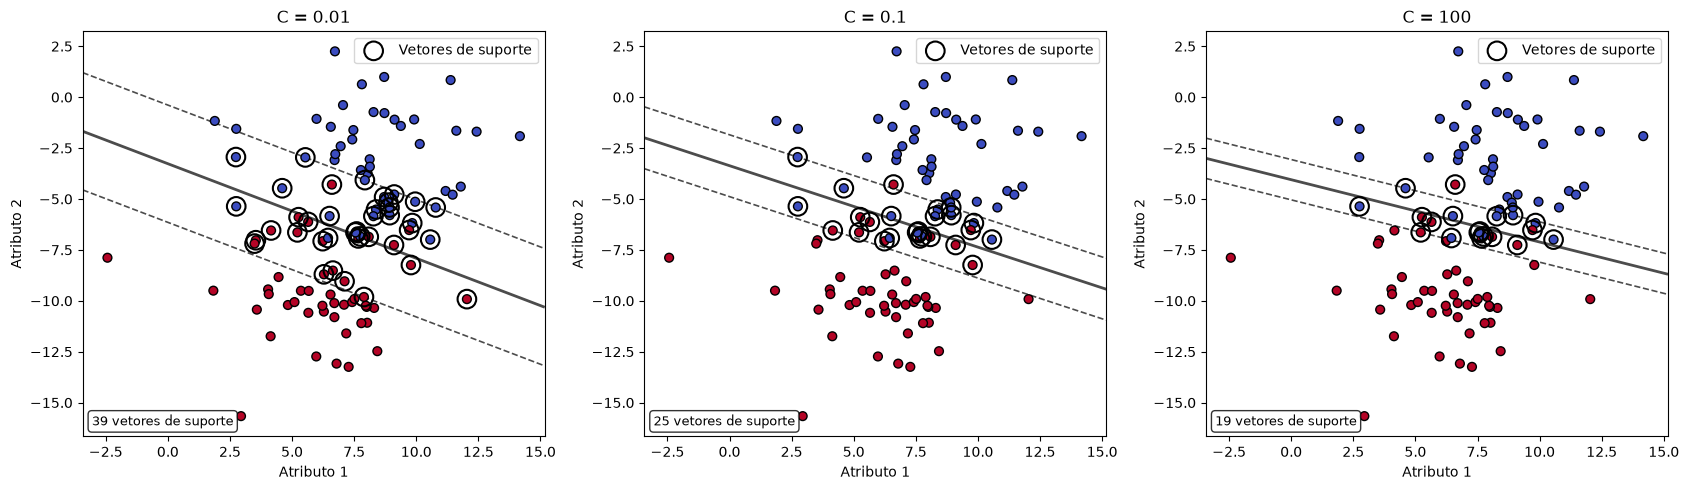

In [39]:
# Gera um conjunto de dados artificial com 100 observações, duas classes e uma sobreposição considerável entre elas.
# O parâmetro cluster_std controla a dispersão dos grupos: quanto maior o valor, maior tende a ser a sobreposição.
X_overlap, y_overlap = make_blobs(
    n_samples=100,
    centers=2,
    cluster_std=2.4,
    random_state=6
)

# Valores do parâmetro de regularização C que serão comparados.
valores_C = [0.01, 0.1, 100]

# Cria uma figura com três gráficos lado a lado, um para cada valor de C.
fig, eixos = plt.subplots(1,3,figsize=(17, 5))

# Percorre simultaneamente os eixos da figura e os valores definidos para C.
for eixo, C in zip(eixos, valores_C):
    # Cria um classificador SVM com kernel linear.
    modelo = SVC(kernel="linear",C=C)
    # Ajusta o modelo usando os dados artificiais.
    modelo.fit(X_overlap,y_overlap)
    # Exibe os dados, a fronteira de decisão, as margens e os vetores de suporte.
    # A função plot_svm foi definida anteriormente.
    plot_svm(modelo,X_overlap,y_overlap,ax=eixo,titulo=f"C = {C}")

    # Conta o número total de vetores de suporte.
    n_sv = len(modelo.support_vectors_)

    # Adiciona ao gráfico uma caixa de texto com o número de vetores de suporte encontrados pelo modelo.
    eixo.text(
        0.02,
        0.02,
        f"{n_sv} vetores de suporte",
        transform=eixo.transAxes,
        fontsize=9,
        verticalalignment="bottom",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8
        )
    )

# Ajusta automaticamente o espaçamento entre os gráficos.
plt.tight_layout()
# Exibe a figura.
plt.show()

Observe a progressão da esquerda para a direita:

- com **$C$ pequeno** (esquerda), a margem é bem larga e o modelo tolera vários pontos dentro dela ou até do lado errado. Essa é uma fronteira simples e suave, mas com mais erros no próprio treino;
- com **$C$ grande** (direita), a margem fica estreita, o modelo tenta acertar praticamente todos os pontos de treino, e o número de vetores de suporte tende a diminuir (só os pontos realmente próximos da fronteira "sobrevivem" como vetores de suporte).

Não existe um valor de $C$ universalmente certo. O valor ideal depende dos dados, e é justamente para isso que vamos usar **validação cruzada** mais adiante.

## O truque do kernel (kernel trick)

Até agora, vimos apenas fronteiras **lineares** (retas). Mas muitos problemas reais não são linearmente separáveis, nem com margem suave. O exemplo clássico: pontos de uma classe formando um círculo interno, e pontos da outra classe formando um anel ao redor. Nenhuma reta separa bem essas duas classes.

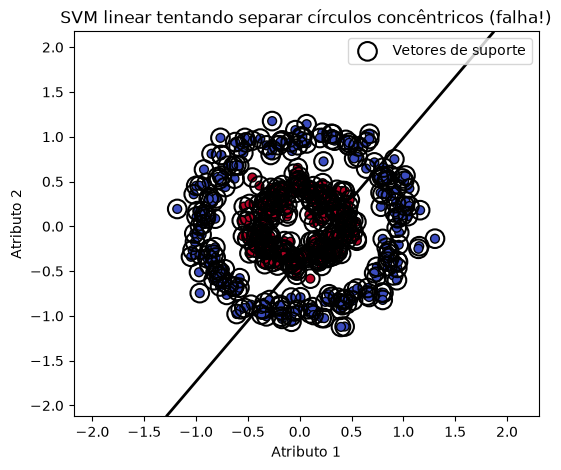

Acurácia do SVM linear neste problema: 58.00%


In [40]:
from sklearn.datasets import make_circles

# Gera 200 observações distribuídas em dois círculos.
# noise=0.1 adiciona uma pequena perturbação aleatória aos dados, tornando o problema mais próximo de uma situação real.
# factor=0.4 define o raio do círculo interno como 40% do raio do círculo externo.
X_circ, y_circ = make_circles(
    n_samples=400,
    noise=0.1,
    factor=0.4,
    random_state=42
)

# Cria um classificador SVM com kernel linear.
# Como os dados estão organizados em círculos concêntricos, não existe uma reta capaz de separar corretamente as duas classes.
modelo_linear_circ = SVC(kernel="linear",C=1)

# Ajusta o modelo aos dados artificiais.
modelo_linear_circ.fit(X_circ,y_circ)

# Exibe os dados e a fronteira de decisão encontrada pelo SVM.
plot_svm(modelo_linear_circ,X_circ,y_circ,titulo="SVM linear tentando separar círculos concêntricos (falha!)",mostrar_margem=False)
plt.show()

# Calcula a acurácia do modelo utilizando os próprios dados empregados no treinamento.
acuracia_linear = modelo_linear_circ.score(X_circ,y_circ)

# Mostra a acurácia em formato percentual, com duas casas decimais.
print(f"Acurácia do SVM linear neste problema: "f"{acuracia_linear:.2%}")

Como esperado, uma fronteira linear não consegue separar adequadamente os dois grupos, e a acurácia tende a ficar próxima daquela obtida por uma classificação aleatória. 

Uma estratégia clássica consiste em **transformar os dados** para um espaço de dimensão maior, no qual as classes possam ser separadas linearmente. Por exemplo, podemos adicionar uma terceira coordenada definida por
$$
z = x_1^2 + x_2^2,
$$
que representa o quadrado da distância de cada ponto até a origem. Como os dois grupos possuem raios diferentes, seus pontos passam a ocupar alturas distintas no novo espaço tridimensional. Assim, os círculos concêntricos são transformados em duas camadas aproximadamente paralelas, que podem ser separadas por um plano. Em outras palavras, **um problema não linearmente separável no espaço original torna-se linearmente separável após a transformação dos atributos**.

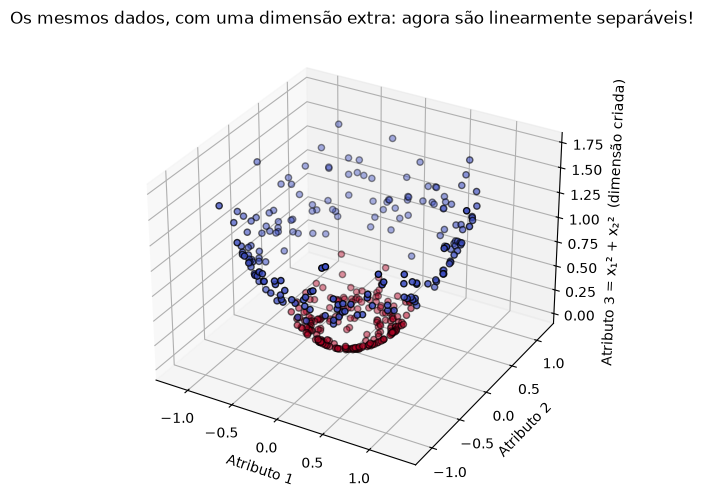

In [41]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necessário para gráficos 3D)

# Cria um novo atributo para cada observação: z= x1^2 + x2^2
z_circ = X_circ[:, 0] ** 2 + X_circ[:, 1] ** 2

# Exibe os dados no espaço tridimensional.
fig = plt.figure(figsize=(7, 6))
ax3d = fig.add_subplot(111, projection="3d")
ax3d.scatter(X_circ[:, 0], X_circ[:, 1], z_circ, c=y_circ, cmap="coolwarm", edgecolors="k")
ax3d.set_xlabel("Atributo 1")
ax3d.set_ylabel("Atributo 2")
ax3d.set_zlabel("Atributo 3 = x₁² + x₂²  (dimensão criada)")
ax3d.set_title("Os mesmos dados, com uma dimensão extra: agora são linearmente separáveis!")
plt.show()

Criar novas dimensões manualmente, como fizemos no exemplo anterior, pode funcionar em problemas simples, mas rapidamente esbarra em um problema de escala. Para representar relações mais complexas entre os atributos, talvez fosse necessário criar dezenas, centenas ou até infinitas novas dimensões. Considere, por exemplo, um conjunto de dados com 100 atributos originais. Se quiséssemos incluir todas as interações de segunda ordem entre atributos distintos, da forma $x_i x_j$, teríamos
$\frac{100\cdot 99}{2} = 4950$ novos atributos. Se também incluíssemos os termos quadráticos $x_i^2$ (mais 100 termos $x_i^2$), o total passaria para 5.050 atributos de grau 2. E isso representa apenas interações relativamente simples. Ao considerar produtos de grau 3, 4 ou superior, o número de dimensões cresce rapidamente. Portanto, calcular, armazenar e processar explicitamente todos esses novos atributos para cada observação pode exigir uma quantidade muito grande de memória e tempo computacional.

O **truque do kernel** (*kernel trick*) contorna esse problema com uma observação elegante. Repare que, em todas as contas do SVM, os dados nunca aparecem sozinhos, eles sempre aparecem **aos pares**, na forma de um produto interno $\mathbf{x}_i^\top \mathbf{x}_j$. E se existisse um atalho para calcular esse produto interno **como se** os dados já tivessem sido transformados para o espaço de maior dimensão, sem nunca de fato construir essa transformação?

Um pequeno exemplo concreto ajuda a ver que isso é realmente possível. Considere dois pontos em duas dimensões, $\mathbf{x}=(x_1,x_2)$ e $\mathbf{y}=(y_1,y_2)$, e a transformação que cria todos os produtos de grau 2: $\phi(\mathbf{x}) = (x_1^2,\ \sqrt{2}\,x_1x_2,\ x_2^2)$. Calculando o produto interno das versões já transformadas:

$$\phi(\mathbf{x})^\top\phi(\mathbf{y}) = x_1^2y_1^2 + 2x_1x_2y_1y_2 + x_2^2y_2^2 = (x_1y_1+x_2y_2)^2 = (\mathbf{x}^\top\mathbf{y})^2$$

Ou seja: **elevar ao quadrado o produto interno original** dá exatamente o mesmo resultado que expandir os dados para três dimensões e só depois calcular o produto interno nesse novo espaço, só que sem nunca precisar montar essas três dimensões. Essa é a ideia por trás de toda função **kernel** $K(\mathbf{x}_i,\mathbf{x}_j)$: ela devolve o valor que o produto interno *teria* em um espaço transformado (às vezes de dimensão altíssima, ou até infinita), calculado inteiramente a partir dos dados originais. O SVM ganha acesso a fronteiras muito mais flexíveis, pagando apenas o custo computacional do espaço original.

Os kernels mais usados na prática:

- **Linear**: $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^\top \mathbf{x}_j$, nenhuma transformação, o produto interno "cru". É o que usamos até agora nesta seção;
- **Polinomial**: $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma\, \mathbf{x}_i^\top \mathbf{x}_j + r)^d$, equivale a criar, implicitamente, todos os produtos e potências dos atributos originais até grau $d$ (exatamente como no exemplo acima, mas generalizado para qualquer grau);
- **RBF** (função de base radial, ou gaussiana): $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \lVert \mathbf{x}_i - \mathbf{x}_j \rVert^2)$, em vez de produtos e potências, mede diretamente o quão "parecidos" (próximos) dois pontos são; corresponde, sem exagero, a um espaço transformado de dimensão **infinita**. É o kernel mais usado na prática, por ser flexível e não exigir a escolha de um grau polinomial.

Vamos aplicar o **kernel RBF** ao mesmo problema dos círculos concêntricos.

No Scikit-Learn (SVC), `gamma='scale'` significa que o modelo calcula um valor automático para o parâmetro gamma usando o número de colunas (features) e a variância dos seus dados.
$$
\gamma = \frac{1}{n_f \times X.var()}
$$
onde $n_f$ é o número de features.

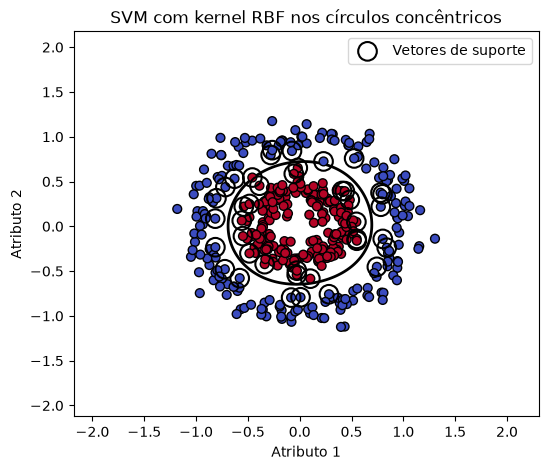

Acurácia do SVM com kernel RBF: 99.75% (contra 58.00% do SVM linear)


In [42]:
# Cria um classificador SVM com kernel RBF.
modelo_rbf_circ = SVC(kernel="rbf",C=1,gamma="scale") # O parâmetro gamma controla a influência de cada ponto de treinamento na decisão do modelo. O valor "scale" é uma escolha padrão que ajusta automaticamente o gamma com base no número de atributos e na variância dos dados.

# Ajusta o modelo utilizando os atributos X_circ e as respectivas classes armazenadas em y_circ.
modelo_rbf_circ.fit(X_circ, y_circ)

# Exibe a fronteira de decisão encontrada pelo SVM.
plot_svm(modelo_rbf_circ,X_circ,y_circ,
         titulo="SVM com kernel RBF nos círculos concêntricos", mostrar_margem=False)
plt.show()

# Calcula a acurácia usando os próprios dados empregados no treinamento do modelo.
acuracia_rbf = modelo_rbf_circ.score(X_circ,y_circ)

# Compara a acurácia do SVM com kernel RBF com a obtida anteriormente pelo SVM com kernel linear.
print(f"Acurácia do SVM com kernel RBF: {acuracia_rbf:.2%} "f"(contra {acuracia_linear:.2%} do SVM linear)")

No kernel RBF, $\gamma$ controla o **alcance de influência** de cada ponto de treino:
$$
K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \lVert \mathbf{x}_i - \mathbf{x}_j \rVert^2)
$$
- **$\gamma$ grande**: a influência de cada ponto é bem localizada (um "morro" estreito ao redor de cada ponto). A fronteira consegue se ajustar a detalhes bem específicos dos dados, mas corre risco de **sobreajuste** (decorar o ruído do treino);
- **$\gamma$ pequeno**: a influência de cada ponto se espalha por uma região ampla. A fronteira fica mais suave e simples, com risco de **subajuste** se for baixo demais.

$\gamma$ desempenha, para o kernel RBF, um papel parecido ao de $C$: ambos controlam a complexidade da fronteira, e ambos precisam ser ajustados com cuidado (normalmente juntos, por validação cruzada).

Na figura a seguir, notem como a fronteira fica cada vez mais "apertada" ao redor dos pontos individuais à medida que $\gamma$ aumenta. No limite, um $\gamma$ excessivamente alto levaria o modelo a basicamente "decorar" cada ponto de treino individualmente, uma fronteira extremamente irregular e com péssima generalização para dados novos.

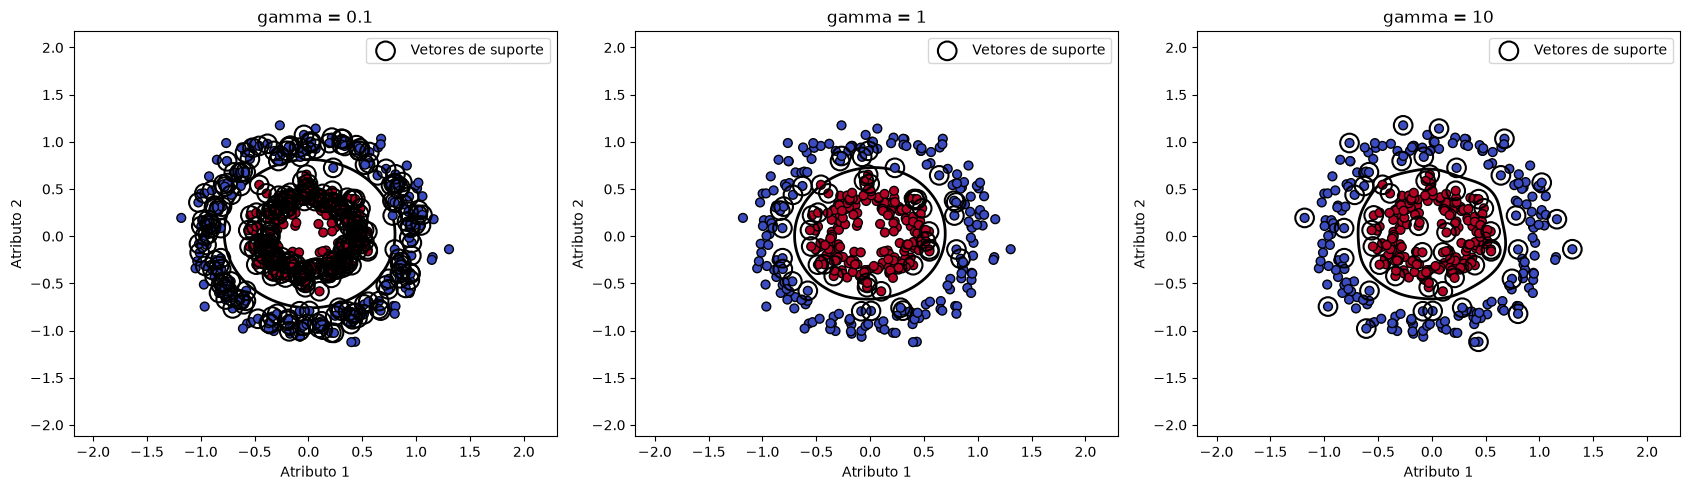

In [43]:
valores_gamma = [0.1, 1, 10]
fig, eixos = plt.subplots(1, 3, figsize=(17, 5))

for eixo, gamma in zip(eixos, valores_gamma):
    modelo = SVC(kernel="rbf", C=1, gamma=gamma)
    modelo.fit(X_circ, y_circ)
    plot_svm(modelo, X_circ, y_circ, ax=eixo, titulo=f"gamma = {gamma}", mostrar_margem=False)

plt.tight_layout()
plt.show()

## 4 - SVM para regressão (SVR)

A mesma ideia de margem pode ser adaptada para problemas de **regressão**, dando origem ao **SVR (Support Vector Regression)**. Em vez de tentar separar classes com a maior margem possível, o SVR tenta ajustar uma função que passe **o mais próximo possível** dos dados, mas com uma regra peculiar:

- Definimos um "tubo" de tolerância de largura $2\varepsilon$ ao redor da função ajustada. Pontos que caem **dentro** desse tubo não são penalizados de forma alguma. Isto é, não importa se estão a $0{,}01$ ou a $\varepsilon$ de distância da função, o erro é tratado como zero. Só os pontos que caem **fora** do tubo contribuem para a função de custo (essa é a chamada *perda insensível a $\varepsilon$*, ou *$\varepsilon$-insensitive loss*).

Isso é bem diferente da regressão linear tradicional (mínimos quadrados), que penaliza **todo** desvio, por menor que seja. A ideia do SVR é: pequenos desvios são apenas ruído aceitável, e só vale a pena "gastar esforço" ajustando o modelo quando o erro for grande o bastante para escapar do tubo.

Assim como na classificação, o SVR também tem:

- um hiperparâmetro **$C$**, que controla o quanto penalizamos os pontos fora do tubo (maior $C$ = menos tolerância a esses desvios, maior risco de sobreajuste);
- um hiperparâmetro **$\varepsilon$**, que controla a largura do tubo (tubo maior = mais pontos ignorados como "ruído aceitável", modelo mais simples);
- a possibilidade de usar **kernels** (linear, polinomial, RBF) para capturar relações não lineares entre os atributos e o alvo, exatamente como na classificação.

Os pontos que ficam **fora** do tubo (ou exatamente na borda) são os **vetores de suporte** da regressão. São eles que determinam o formato da função ajustada.

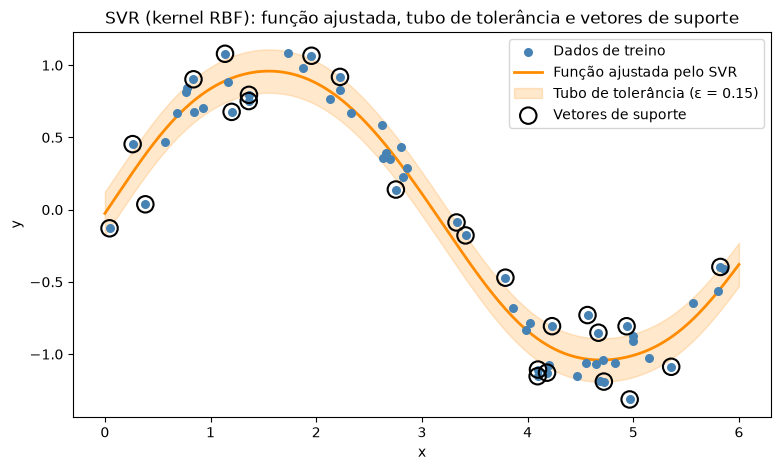

Número de vetores de suporte: 25 (de 60 pontos no total)
Note que só os pontos FORA do tubo (ou bem na borda) viram vetores de suporte.


In [44]:
from sklearn.svm import SVR
# Cria um gerador de números aleatórios.
rng = np.random.default_rng(42)

# Gera 60 valores aleatórios uniformemente distribuídos no intervalo entre 0 e 6.
# np.sort organiza os valores em ordem crescente, facilitando posteriormente a visualização dos dados.
# reshape(-1, 1) transforma o vetor em uma matriz com uma única coluna, formato esperado pelos modelos do scikit-learn.
X_reg = np.sort(
    rng.uniform(0, 6, 60)
).reshape(-1, 1)

# Gera a variável resposta a partir da função seno.
# O método ravel() transforma o resultado em um vetor unidimensional.
# Em seguida, adiciona-se um ruído aleatório com distribuição normal, média zero e desvio-padrão igual a 0,2.
y_reg = (
    np.sin(X_reg).ravel()
    + rng.normal(
        loc=0,
        scale=0.2,
        size=X_reg.shape[0]
    )
)

# Cria o modelo SVR com kernel RBF.
svr_rbf = SVR(kernel="rbf", C=10, epsilon=0.15, gamma=0.5)
# Ajusta o modelo aos dados de regressão.
svr_rbf.fit(X_reg, y_reg)

# faz a predição
X_plot = np.linspace(0, 6, 300).reshape(-1, 1)
y_plot = svr_rbf.predict(X_plot)

# mostra os resultados
plt.figure(figsize=(9, 5))
plt.scatter(X_reg, y_reg, color="steelblue", s=30, label="Dados de treino", zorder=3)
plt.plot(X_plot, y_plot, color="darkorange", lw=2, label="Função ajustada pelo SVR")
plt.fill_between(X_plot.ravel(), y_plot - svr_rbf.epsilon, y_plot + svr_rbf.epsilon,
                  color="darkorange", alpha=0.2, label=f"Tubo de tolerância (ε = {svr_rbf.epsilon})")

indices_sv = svr_rbf.support_
plt.scatter(X_reg[indices_sv], y_reg[indices_sv], s=140, facecolors="none",
            edgecolors="black", linewidths=1.5, label="Vetores de suporte", zorder=4)

plt.title("SVR (kernel RBF): função ajustada, tubo de tolerância e vetores de suporte")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper right")
plt.show()

print(f"Número de vetores de suporte: {len(indices_sv)} (de {len(X_reg)} pontos no total)")
print("Note que só os pontos FORA do tubo (ou bem na borda) viram vetores de suporte.")

Repare como os pontos **dentro** do tubo laranja (a maioria) não são marcados como vetores de suporte, isto é, eles não influenciam a forma da curva ajustada. Apenas os pontos que ficam fora do tubo (ou muito perto da borda) "puxam" a função para se ajustar a eles.

Na SVR, o modelo fornece uma função que pode ser usada para realizar previsões. A forma dessa função depende do kernel utilizado.
Para um SVR com kernel linear, a função de regressão é dada por:
$$
\hat{y}(\mathbf{x})=\mathbf{w}^{T}\mathbf{x}+b,
$$
em que $\mathbf{w}$ é o vetor de coeficientes, $\mathbf{x}$ é o vetor de atributos e $b$ é o intercepto.

No caso de uma única variável, essa equação pode ser escrita como:
$$
\hat{y}(x)=wx+b.
$$
Portanto, com o kernel linear, o SVR fornece uma equação semelhante à encontrada na regressão linear.

Vamos considerar o caso linear abaixo.

Coeficiente angular: 3.0260
Intercepto: 2.0375
Equação estimada: ŷ = 3.0260x + 2.0375


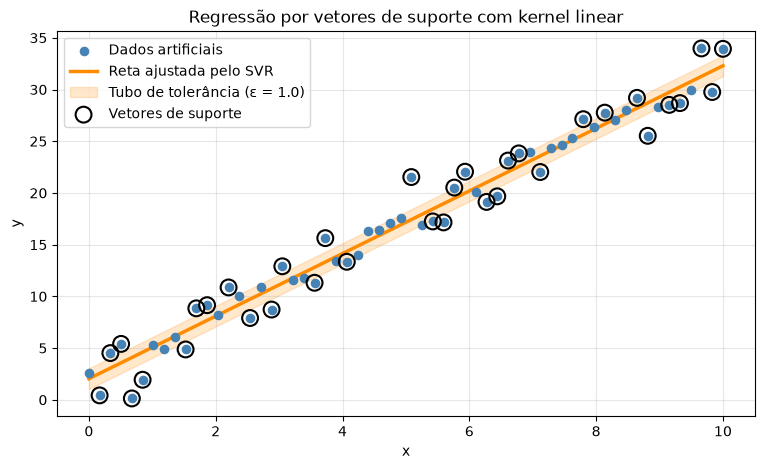

Erro quadrático médio: 2.4167
Coeficiente de determinação R²: 0.9706
Número de vetores de suporte: 34


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Gerador de números aleatórios para permitir a reprodução dos mesmos resultados.
rng = np.random.default_rng(42)

# Gera 60 valores igualmente espaçados entre 0 e 10.
# O reshape transforma o vetor em uma matriz com uma coluna, formato esperado pelo scikit-learn.
X = np.linspace(0, 10, 60).reshape(-1, 1)

# Relação linear verdadeira utilizada para gerar os dados:
# y = 3x + 2 + ruído
# O ruído segue uma distribuição normal com média zero
# e desvio-padrão igual a sigma.
y = 3 * X.ravel() + 2 + rng.normal(
    loc=0,
    scale=2,
    size=X.shape[0]
)

# Cria um modelo de regressão por vetores de suporte com kernel linear.
# C controla a penalização dos erros e epsilon define a largura do tubo de tolerância.
modelo_svr = SVR(
    kernel="linear",
    C=10,
    epsilon=1.0
)

# Ajusta o modelo aos dados.
modelo_svr.fit(X, y)

# Para o kernel linear, coef_ contém o coeficiente angular e intercept_ contém o intercepto.
coeficiente = modelo_svr.coef_[0, 0]
intercepto = modelo_svr.intercept_[0]
print(f"Coeficiente angular: {coeficiente:.4f}")
print(f"Intercepto: {intercepto:.4f}")

print(f"Equação estimada: "f"ŷ = {coeficiente:.4f}x + {intercepto:.4f}")

# Cria pontos para desenhar a reta ajustada.
X_plot = np.linspace(X.min(),X.max(),300).reshape(-1, 1)

# Calcula as previsões do modelo.
y_plot = modelo_svr.predict(X_plot)

# Limites superior e inferior do tubo de tolerância.
limite_superior = y_plot + modelo_svr.epsilon
limite_inferior = y_plot - modelo_svr.epsilon

# Índices dos vetores de suporte.
indices_sv = modelo_svr.support_

# mostra os resultados
plt.figure(figsize=(9, 5))
# Dados artificiais.
plt.scatter(X,y,color="steelblue",s=35,label="Dados artificiais",zorder=3)
# Reta ajustada pelo SVR.
plt.plot(X_plot,y_plot,color="darkorange",linewidth=2.5,label="Reta ajustada pelo SVR")

# Tubo de tolerância.
plt.fill_between(X_plot.ravel(),limite_inferior,limite_superior,color="darkorange",alpha=0.2,
    label=(f"Tubo de tolerância "f"(ε = {modelo_svr.epsilon})"))
# Destaca os vetores de suporte.
plt.scatter(X[indices_sv],y[indices_sv],s=130,facecolors="none",edgecolors="black",linewidths=1.5,label="Vetores de suporte",zorder=4)

plt.title("Regressão por vetores de suporte com kernel linear")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# avaliação do ajuste
# Previsões para os dados usados no treinamento.
y_pred = modelo_svr.predict(X)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f"Erro quadrático médio: {mse:.4f}")
print(f"Coeficiente de determinação R²: {r2:.4f}")
print(f"Número de vetores de suporte: {len(indices_sv)}")

Um ponto importante no SVM é a questão da escala. O SVM depende diretamente de **distâncias** e **produtos internos** entre os pontos (isso fica explícito na fórmula do kernel RBF, que usa $\lVert \mathbf{x}_i - \mathbf{x}_j \rVert^2$). Se um atributo tiver uma escala muito maior que os outros (por exemplo, "salário anual" variando na casa dos milhares, contra "idade" variando de 0 a 100), esse atributo vai **dominar** o cálculo de distância, tornando os demais atributos quase irrelevantes para o modelo, mesmo que eles sejam informativos.

Vamos ilustrar isso de forma direta: usamos os mesmos dados, mas com o Atributo 2 multiplicado por 50 (como se estivesse em uma unidade de medida bem maior), sem reescalonar.

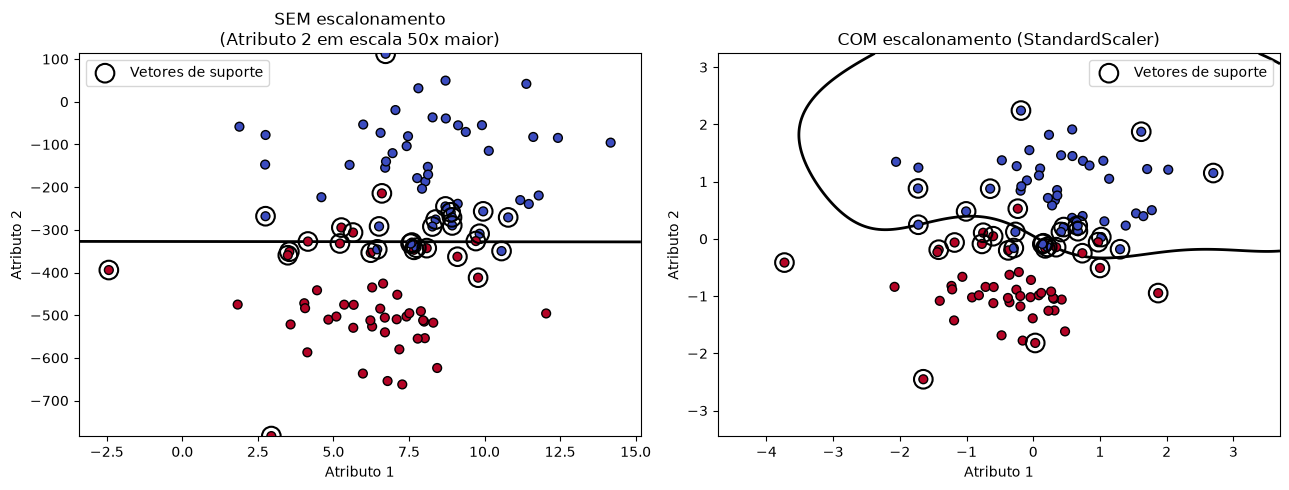

In [46]:
from sklearn.preprocessing import StandardScaler

X_desbalanceado = X_overlap.copy()
X_desbalanceado[:, 1] = X_desbalanceado[:, 1] * 50  # simula um atributo em escala bem maior

fig, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(13, 5))

modelo_sem_escala = SVC(kernel="rbf", C=1, gamma="scale")
modelo_sem_escala.fit(X_desbalanceado, y_overlap)
plot_svm(modelo_sem_escala, X_desbalanceado, y_overlap, ax=eixo1,
                     titulo="SEM escalonamento\n(Atributo 2 em escala 50x maior)", mostrar_margem=False)

X_com_escala = StandardScaler().fit_transform(X_desbalanceado)
modelo_com_escala = SVC(kernel="rbf", C=1, gamma="scale")
modelo_com_escala.fit(X_com_escala, y_overlap)
plot_svm(modelo_com_escala, X_com_escala, y_overlap, ax=eixo2,
                     titulo="COM escalonamento (StandardScaler)", mostrar_margem=False)

plt.tight_layout()
plt.show()

Sem escalonamento, a fronteira fica quase totalmente definida pelo Atributo 2 (a escala maior domina o cálculo de distância do kernel RBF), ignorando praticamente toda a informação do Atributo 1. Depois de padronizar os dados (média zero, desvio padrão um, com `StandardScaler`), os dois atributos passam a contribuir de forma equilibrada.

Na prática, sempre padronize os atributos antes de treinar um SVM (exceto quando os atributos já estiverem naturalmente na mesma escala).

## Aplicação em dados reais: classificação

Vamos aplicar tudo o que vimos a um problema real: a classificação de silhuetas de veículos a partir de atributos geométricos extraídos de imagens (o conjunto *Statlog (Vehicle Silhouettes)*). Cada linha descreve o contorno de um veículo por meio de 18 atributos numéricos (compacidade, circularidade, razões de aspecto, momentos estatísticos da silhueta etc.), e o alvo indica a que categoria o veículo pertence: **ônibus** (`bus`), **van** (`van`), ou um dos dois modelos de carro, **opel** ou **saab**.

Os dados estão disponíveis como um arquivo CSV (`data/Vehicle.csv`). Como antes, trabalhamos sempre **lendo do arquivo**, como aconteceria com qualquer dado real recebido de terceiros.

In [47]:
import os
import pandas as pd

caminho_csv_vehicle = r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\Vehicle.csv"

if not os.path.exists(caminho_csv_vehicle):
    raise FileNotFoundError(
        f"Não encontrei o arquivo em '{caminho_csv_vehicle}'. Baixe o conjunto "
        "Statlog (Vehicle Silhouettes) e salve-o nesse caminho antes de continuar."
    )

dados = pd.read_csv(caminho_csv_vehicle)
print("Dimensão dos dados:", dados.shape)
dados.head()

Dimensão dos dados: (846, 19)


,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus


Distribuição das classes:


Class
bus     218
saab    217
opel    212
van     199
Name: count, dtype: int64

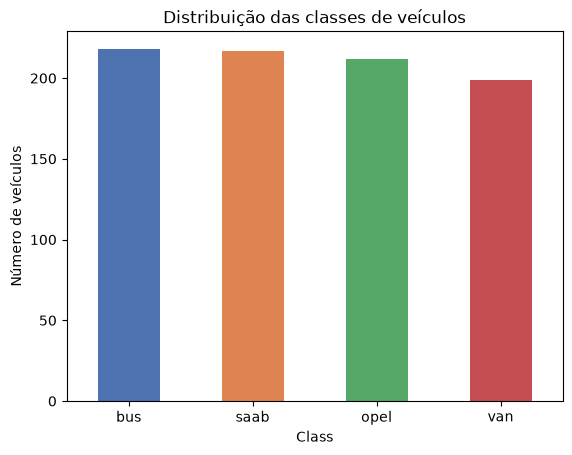

In [48]:
import matplotlib.pyplot as plt

print("Distribuição das classes:")
display(dados["Class"].value_counts())

dados["Class"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
plt.xticks(rotation=0)
plt.ylabel("Número de veículos")
plt.title("Distribuição das classes de veículos")
plt.show()

As quatro classes estão bem balanceadas entre si (nenhuma domina as demais). Vamos separar os atributos (`X`) do alvo (`y`). Como agora temos 4 classes em vez de 2, não há necessidade de codificar o alvo como 0/1: o próprio `SVC` do scikit-learn lida nativamente com problemas multiclasse.

Vamos selecionar X e y.

In [49]:
X = dados.drop(columns=["Class"])
y = dados["Class"]

Separamos os conjuntos de treinamento e teste.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# separa os conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print("Treinamento:", X_train.shape)
print("Teste:  ", X_test.shape)

Treinamento: (676, 18)
Teste:   (170, 18)


Criamos o pipeline que leva em conta a padronização e a classificação via SVM.

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipeline_svc = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])

Vamos buscar, por validação cruzada, os melhores hiperparâmetros do SVM. Como o kernel linear não usa $\gamma$, organizamos a busca em **duas grades separadas** (uma para cada kernel), o que é o jeito correto de combinar hiperparâmetros que só fazem sentido para determinados valores de outro hiperparâmetro.

In [52]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grade_hiperparametros = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1]
    }
]

busca_svc = GridSearchCV(
    estimator=pipeline_svc,
    param_grid=grade_hiperparametros,
    scoring="roc_auc_ovr",
    cv=cv_split,
    n_jobs=-1,
    refit=True
)

busca_svc.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:", busca_svc.best_params_)
print(f"Melhor AUC média (um-contra-todos) na validação cruzada: {busca_svc.best_score_:.4f}")

Melhores hiperparâmetros encontrados: {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Melhor AUC média (um-contra-todos) na validação cruzada: 0.9602


Vale a pena olhar não só o melhor resultado, mas também **como a performance varia** com $C$ e $\gamma$ — isso ajuda a entender se o modelo é sensível a esses hiperparâmetros (o que sugeriria cautela) ou se há uma região ampla de bons valores (o que sugere um ajuste mais robusto).

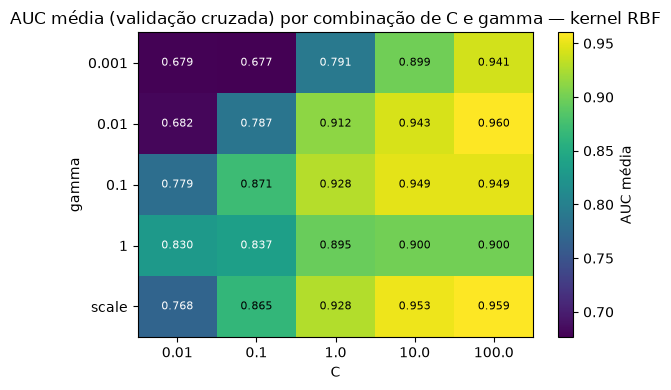

In [53]:
resultados_grid = pd.DataFrame(busca_svc.cv_results_)
resultados_rbf = resultados_grid[resultados_grid["param_svm__kernel"] == "rbf"].copy()

tabela_pivot = resultados_rbf.pivot_table(
    index="param_svm__gamma", columns="param_svm__C", values="mean_test_score"
)

plt.figure(figsize=(6, 4))
plt.imshow(tabela_pivot.values, cmap="viridis", aspect="auto")
plt.xticks(range(len(tabela_pivot.columns)), tabela_pivot.columns)
plt.yticks(range(len(tabela_pivot.index)), tabela_pivot.index)
plt.xlabel("C")
plt.ylabel("gamma")
plt.title("AUC média (validação cruzada) por combinação de C e gamma — kernel RBF")
plt.colorbar(label="AUC média")
for i in range(len(tabela_pivot.index)):
    for j in range(len(tabela_pivot.columns)):
        valor = tabela_pivot.values[i, j]
        plt.text(j, i, f"{valor:.3f}", ha="center", va="center",
                  color="white" if valor < tabela_pivot.values.mean() else "black", fontsize=8)
plt.tight_layout()
plt.show()

Com os melhores hiperparâmetros em mãos, vamos avaliar o modelo no conjunto de teste (que não participou da busca de hiperparâmetros). Como agora temos **4 classes** em vez de 2, precisão, recall e F1 precisam ser calculados por classe e depois combinados — usamos a média **macro** (a média simples entre as classes, tratando todas com o mesmo peso, independentemente do tamanho):

- **acurácia**: proporção geral de acertos;
- **precisão (precision) macro**: média, entre as 4 classes, da fração de previsões de cada classe que estavam corretas (mede o custo de falsos positivos);
- **recall (sensibilidade) macro**: média, entre as 4 classes, da fração de casos de cada classe corretamente identificados (mede o custo de falsos negativos);
- **F1 macro**: média harmônica entre precisão e recall, calculada por classe e depois combinada;
- **AUC-ROC (um-contra-todos,** *one-vs-rest***)**: para cada classe, mede a capacidade do modelo de separá-la das demais, considerando todos os limiares de decisão possíveis; a métrica final é a média entre as 4 classes.

In [54]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
)

melhor_svc = busca_svc.best_estimator_

y_pred = melhor_svc.predict(X_test)
y_prob = melhor_svc.predict_proba(X_test)

metricas_svc = {
    "Acurácia": accuracy_score(y_test, y_pred),
    "Precisão (macro)": precision_score(y_test, y_pred, average="macro"),
    "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
    "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
    "AUC (ovr, macro)": roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
}

metricas_svc_df = pd.DataFrame([metricas_svc], index=["SVM (RBF)"])
display(metricas_svc_df.round(4))

print("\nRelatório de classificação completo:")
print(classification_report(y_test, y_pred, digits=4))

,Acurácia,Precisão (macro),Recall (macro),F1 (macro),"AUC (ovr, macro)"
SVM (RBF),0.8529,0.852,0.8533,0.8512,0.9627



Relatório de classificação completo:
              precision    recall  f1-score   support

         bus     0.9778    1.0000    0.9888        44
        opel     0.7500    0.6429    0.6923        42
        saab     0.7292    0.7955    0.7609        44
         van     0.9512    0.9750    0.9630        40

    accuracy                         0.8529       170
   macro avg     0.8520    0.8533    0.8512       170
weighted avg     0.8509    0.8529    0.8505       170



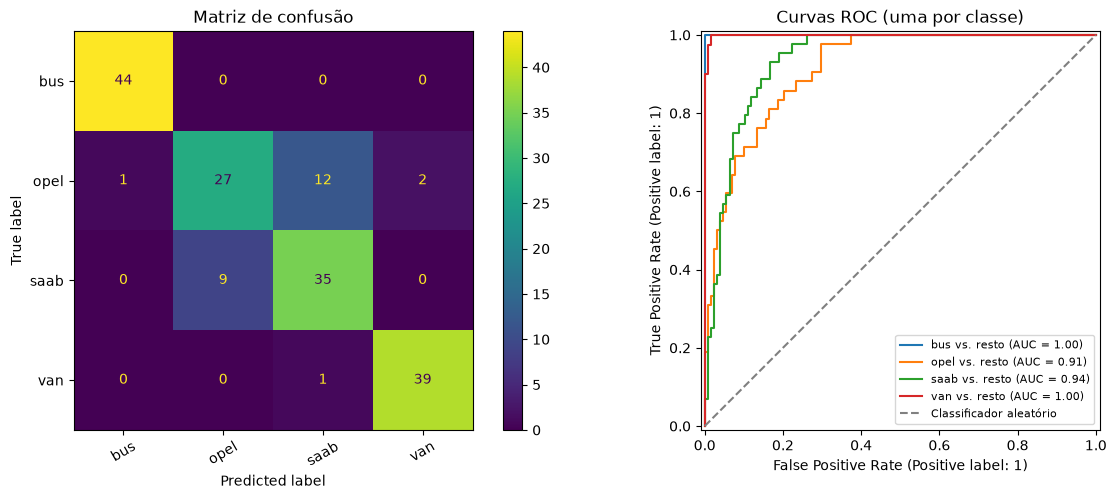

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=melhor_svc.named_steps["svm"].classes_,
    values_format="d", ax=eixo1, xticks_rotation=30
)
eixo1.set_title("Matriz de confusão")

# Com mais de duas classes, plotamos uma curva ROC "um-contra-todos" para cada classe
for i, classe in enumerate(melhor_svc.named_steps["svm"].classes_):
    RocCurveDisplay.from_predictions(
        (y_test == classe).astype(int), y_prob[:, i], name=f"{classe} vs. resto", ax=eixo2
    )
eixo2.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificador aleatório")
eixo2.set_title("Curvas ROC (uma por classe)")
eixo2.legend(fontsize=8)

plt.tight_layout()
plt.show()

Diferentemente de um problema de diagnóstico médico, aqui não há uma classe cujo erro seja "mais grave" por natureza, mas a matriz de confusão e o relatório de classificação revelam algo interessante: **`bus` e `van`** tendem a ser identificados quase perfeitamente, enquanto **`opel` e `saab`** são frequentemente confundidos entre si. Isso não é uma falha do modelo: as silhuetas desses dois modelos de carro são, de fato, muito parecidas do ponto de vista das medidas geométricas usadas como atributos. É uma limitação dos próprios dados, não do classificador. Em uma aplicação real (por exemplo, um sistema de triagem automática em um pedágio), essa informação ajudaria a decidir se vale a pena investir em atributos adicionais para diferenciar melhor esses dois modelos, ou se essa confusão é aceitável para o objetivo do sistema.

Podemos inspecionar quantos dos 634 pontos de treinamento se tornaram vetores de suporte, o que é uma medida indireta de quão "simples" ou "complexa" ficou a fronteira encontrada. Como agora temos 4 classes, o SVM internamente treina um classificador binário para cada par de classes (estratégia **um-contra-um**, *one-vs-one*) — por isso `n_support_` traz uma contagem de vetores de suporte para cada uma das 4 classes.

In [56]:
netores_suporte = melhor_svc.named_steps["svm"].n_support_
classes_svm = melhor_svc.named_steps["svm"].classes_

for classe, n in zip(classes_svm, netores_suporte):
    print(f"Vetores de suporte da classe '{classe}': {n}")

print(f"Total: {netores_suporte.sum()} de {len(X_train)} pontos de treinamento "
      f"({100 * netores_suporte.sum() / len(X_train):.1f}%)")

Vetores de suporte da classe 'bus': 35
Vetores de suporte da classe 'opel': 121
Vetores de suporte da classe 'saab': 127
Vetores de suporte da classe 'van': 40
Total: 323 de 676 pontos de treinamento (47.8%)


As classes opel e saab concentraram a maior parte dos vetores de suporte. Esse resultado sugere que essas duas classes são mais difíceis de separar. Provavelmente apresentam maior sobreposição entre si ou com outras classes, exigindo mais observações para definir adequadamente as fronteiras de decisão. Já as classes bus e van utilizaram poucos vetores de suporte. Isso indica que essas classes tendem a ocupar regiões mais bem separadas no espaço de atributos. Assim, um número menor de pontos é suficiente para estabelecer suas fronteiras. De modo geral, o resultado indica que o SVM consegue separar bus e van com maior facilidade, enquanto encontra maior dificuldade para distinguir opel e saab.

## Aplicação em dados reais: regressão

Agora vamos aplicar o **SVR** a um problema real de regressão: prever a **progressão da diabetes** um ano após a linha de base, a partir de 10 variáveis clínicas (idade, sexo, IMC, pressão arterial e seis medidas de exames de sangue). O alvo é um valor numérico contínuo que mede a evolução da doença — quanto maior, pior a progressão.

Como antes, os dados estão em um arquivo CSV (`data/diabetes/diabetes.csv`), que criamos a partir do conjunto de dados público do scikit-learn caso ainda não exista, e depois lemos normalmente com `pd.read_csv`.

In [69]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

# Cria um DataFrame com os dados e os nomes das colunas.
dados_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
print("Dimensão dos dados:", dados_diabetes.shape)

# Criar série com o alvo
diabetes_target = pd.Series(diabetes.target, name="target")
print("Dimensão do alvo:", diabetes_target.shape)   
dados_diabetes.head(10)


Dimensão dos dados: (442, 10)
Dimensão do alvo: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504


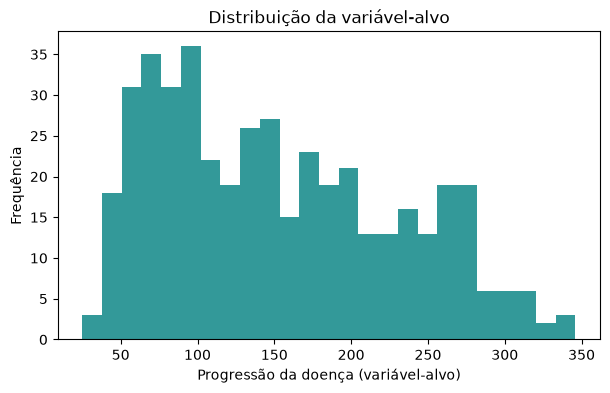

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


In [70]:
plt.figure(figsize=(7, 4))
plt.hist(diabetes_target, bins=25, color="teal", alpha=0.8)
plt.xlabel("Progressão da doença (variável-alvo)")
plt.ylabel("Frequência")
plt.title("Distribuição da variável-alvo")
plt.show()

print(diabetes_target.describe())

Vamos criar os conjuntos de treinamento e teste e o pipeline.

In [71]:
from sklearn.svm import SVR
import numpy as np

X = dados_diabetes
y = diabetes_target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Treinamento:", X_train.shape)
print("Validação:  ", X_test.shape)

pipeline_svr = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

Treinamento: (353, 10)
Validação:   (89, 10)


Para o SVR, buscamos simultaneamente $C$ (regularização), $\varepsilon$ (largura do tubo de tolerância) e, para o kernel RBF, $\gamma$. Usamos o **erro quadrático médio negativo** (`neg_mean_squared_error`) como métrica de pontuação. O scikit-learn sempre maximiza a métrica de pontuação internamente, então usamos a versão negativa do erro (assim, "menos erro" continua significando "pontuação maior").

In [72]:
grade_hiperparametros_svr = [
    {
        "svr__kernel": ["linear"],
        "svr__C": [0.1, 1, 10, 100],
        "svr__epsilon": [0.01, 0.1, 0.5, 1]
    },
    {
        "svr__kernel": ["rbf"],
        "svr__C": [0.1, 1, 10, 100],
        "svr__epsilon": [0.01, 0.1, 0.5, 1],
        "svr__gamma": ["scale", 0.001, 0.01, 0.1]
    }
]

busca_svr = GridSearchCV(
    estimator=pipeline_svr,
    param_grid=grade_hiperparametros_svr,
    scoring="neg_mean_squared_error", # erro quadrático negativo
    cv=5,
    n_jobs=-1,
    refit=True
)
# ajusta o modelo
busca_svr.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:", busca_svr.best_params_)
print(f"Melhor RMSE médio na validação cruzada: {np.sqrt(-busca_svr.best_score_):.2f}") 

Melhores hiperparâmetros encontrados: {'svr__C': 1, 'svr__epsilon': 1, 'svr__kernel': 'linear'}
Melhor RMSE médio na validação cruzada: 55.68


Vamos fazer a avaliação no conjunto de validação.

Para regressão, as métricas clássicas são:

- **MAE (erro absoluto médio)**: média de $|y_{\text{real}} - y_{\text{previsto}}|$ — fácil de interpretar, na mesma unidade do alvo;
- **MSE (erro quadrático médio)**: média de $(y_{\text{real}} - y_{\text{previsto}})^2$ — penaliza mais fortemente erros grandes;
- **RMSE (raiz do erro quadrático médio)**: raiz quadrada do MSE, o que devolve a métrica à unidade original do alvo (mais interpretável que o MSE);
- **R² (coeficiente de determinação)**: proporção da variância do alvo que o modelo consegue explicar; $R^2 = 1$ é ajuste perfeito, $R^2 = 0$ equivale a sempre prever a média, e valores negativos indicam um modelo pior do que simplesmente prever a média.

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

melhor_svr = busca_svr.best_estimator_
y_pred = melhor_svr.predict(X_test)

metricas_svr = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "R²": r2_score(y_test, y_pred)
}

metricas_svr_df = pd.DataFrame([metricas_svr], index=["SVR"])
display(metricas_svr_df.round(3))

print(f"\nPara referência, o desvio padrão da variável-alvo é {y.std():.2f}.")
print(f"Um MAE de {metricas_svr['MAE']:.2f} significa um erro médio de previsão bem menor que essa variação natural dos dados.")

,MAE,MSE,RMSE,R²
SVR,43.343,2935.905,54.184,0.446



Para referência, o desvio padrão da variável-alvo é 77.09.
Um MAE de 43.34 significa um erro médio de previsão bem menor que essa variação natural dos dados.


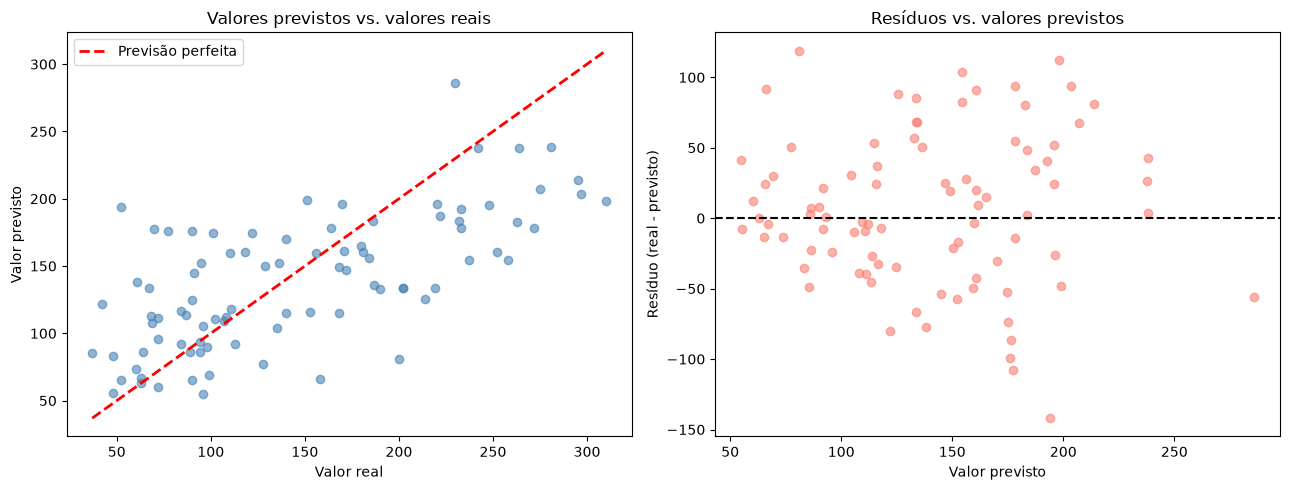

In [74]:
fig, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(13, 5))

eixo1.scatter(y_test, y_pred, alpha=0.6, color="steelblue")
limite_min = min(y_test.min(), y_pred.min())
limite_max = max(y_test.max(), y_pred.max())
eixo1.plot([limite_min, limite_max], [limite_min, limite_max], "r--", lw=2, label="Previsão perfeita")
eixo1.set_xlabel("Valor real")
eixo1.set_ylabel("Valor previsto")
eixo1.set_title("Valores previstos vs. valores reais")
eixo1.legend()

residuos = y_test - y_pred
eixo2.scatter(y_pred, residuos, alpha=0.6, color="salmon")
eixo2.axhline(0, color="black", linestyle="--", lw=1.5)
eixo2.set_xlabel("Valor previsto")
eixo2.set_ylabel("Resíduo (real - previsto)")
eixo2.set_title("Resíduos vs. valores previstos")

plt.tight_layout()
plt.show()

No gráfico da esquerda, quanto mais próximos os pontos estiverem da linha tracejada (previsão perfeita), melhor o modelo. No gráfico da direita, queremos que os resíduos estejam **espalhados aleatoriamente ao redor de zero**, sem nenhum padrão sistemático (um padrão em forma de funil, curva ou tendência indicaria que o modelo está sistematicamente errando de um jeito específico, algo que boas features ou um modelo diferente poderiam corrigir).

### Comparação com um modelo linear simples

Vale sempre comparar o SVR com uma baseline simples. Neste caso, uma regressão linear comum — para checar se a maior complexidade do SVM realmente compensa.

In [75]:
from sklearn.linear_model import LinearRegression

pipeline_linear = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])
pipeline_linear.fit(X_train, y_train)
y_pred_linear = pipeline_linear.predict(X_test)

comparacao_regressao = pd.DataFrame({
    "MAE": [mean_absolute_error(y_test, y_pred), mean_absolute_error(y_test, y_pred_linear)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred)), np.sqrt(mean_squared_error(y_test, y_pred_linear))],
    "R²": [r2_score(y_test, y_pred), r2_score(y_test, y_pred_linear)]
}, index=["SVR", "Regressão linear"])

display(comparacao_regressao.round(3))

,MAE,RMSE,R²
SVR,43.343,54.184,0.446
Regressão linear,42.794,53.853,0.453


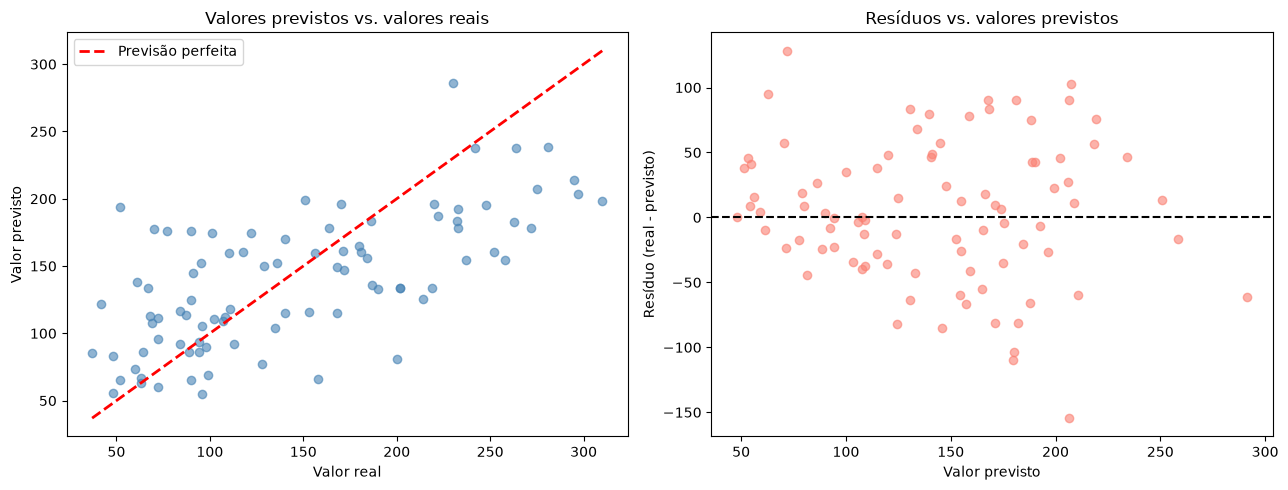

In [76]:
fig, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(13, 5))

eixo1.scatter(y_test, y_pred, alpha=0.6, color="steelblue")
limite_min = min(y_test.min(), y_pred_linear.min())
limite_max = max(y_test.max(), y_pred_linear.max())
eixo1.plot([limite_min, limite_max], [limite_min, limite_max], "r--", lw=2, label="Previsão perfeita")
eixo1.set_xlabel("Valor real")
eixo1.set_ylabel("Valor previsto")
eixo1.set_title("Valores previstos vs. valores reais")
eixo1.legend()

residuos = y_test - y_pred_linear
eixo2.scatter(y_pred_linear, residuos, alpha=0.6, color="salmon")
eixo2.axhline(0, color="black", linestyle="--", lw=1.5)
eixo2.set_xlabel("Valor previsto")
eixo2.set_ylabel("Resíduo (real - previsto)")
eixo2.set_title("Resíduos vs. valores previstos")

plt.tight_layout()
plt.show()

Como o melhor kernel encontrado pela validação cruzada foi o **linear**, é esperado que o SVR tenha um desempenho parecido com o de uma regressão linear comum neste conjunto de dados, o que sugere que a relação entre os atributos clínicos e a progressão da diabetes é, em grande parte, **aproximadamente linear**. Isso é, em si, uma conclusão importante: a maior flexibilidade do kernel RBF não ajudou aqui porque não havia padrão não linear relevante a ser capturado. Esse é outro lembrete de que vale a pena deixar a validação cruzada decidir, em vez de assumir de antemão que um kernel mais complexo é sempre melhor.

### Exercícios de fixação

1. Repita a aplicação de classificação usando o kernel polinomial (`kernel='poly'`), incluindo o grau (`degree`) na busca de hiperparâmetros. Ele supera o kernel RBF encontrado?

### Passo 1 - repetir a análise com kernel RBF

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

caminho_csv_vehicle = r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\Vehicle.csv"

# Lê o arquivo CSV contendo os dados do conjunto Statlog (Vehicle Silhouettes)
dados = pd.read_csv(caminho_csv_vehicle)
print("Dimensão dos dados:", dados.shape)

# 
X = dados.drop(columns=["Class"])
y = dados["Class"]


# separa os conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print("Treinamento:", X_train.shape)
print("Teste:  ", X_test.shape)

# Cria um pipeline que primeiro aplica o escalonamento dos dados e depois treina um classificador SVM.
pipeline_svc = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])


# Define a estratégia de validação cruzada estratificada com 5 folds, garantindo que a proporção das classes seja mantida em cada fold.
cv_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define a grade de hiperparâmetros a ser testada durante a busca em grade (Grid Search).
grade_hiperparametros = [
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1]
    }
]

# Configura a busca em grade (Grid Search) para encontrar os melhores hiperparâmetros do classificador SVM.
busca_svc = GridSearchCV(
    estimator=pipeline_svc,
    param_grid=grade_hiperparametros,
    scoring="roc_auc_ovr",
    cv=cv_split,
    n_jobs=-1,
    refit=True
)

busca_svc.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:", busca_svc.best_params_)
print(f"Melhor AUC média (um-contra-todos) na validação cruzada: {busca_svc.best_score_:.4f}")

# Exibe a média e o desvio padrão da métrica de avaliação (AUC) para o melhor modelo encontrado, bem como os valores obtidos em cada fold da validação cruzada.
i = busca_svc.best_index_
cv = busca_svc.cv_results_
print("\nResultados detalhados da busca em grade:")
print(f"Média: {cv['mean_test_score'][i]:.4f} ± {cv['std_test_score'][i]:.4f}")
print("Por fold:", [round(cv[f'split{k}_test_score'][i], 4) for k in range(5)])

Dimensão dos dados: (846, 19)
Treinamento: (676, 18)
Teste:   (170, 18)
Melhores hiperparâmetros encontrados: {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Melhor AUC média (um-contra-todos) na validação cruzada: 0.9602

Resultados detalhados da busca em grade:
Média: 0.9602 ± 0.0058
Por fold: [np.float64(0.9646), np.float64(0.9577), np.float64(0.9689), np.float64(0.9523), np.float64(0.9578)]


### Passo 2 - Repetir a análise com kernel polynomial, comparando os resultados com o kernel RBF.

In [90]:
# Define a nova grade de hiperparâmetros a ser testada durante a busca em grade (Grid Search).
grade_hiperparametros = [
    {
        "svm__kernel": ["poly"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1],
        "svm__degree": [2, 3, 4]
    }
]

# Configura a busca em grade (Grid Search) para encontrar os melhores hiperparâmetros do classificador SVM.
busca_svc = GridSearchCV(
    estimator=pipeline_svc,
    param_grid=grade_hiperparametros,
    scoring="roc_auc_ovr",
    cv=cv_split,
    n_jobs=-1,
    refit=True
)

busca_svc.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:", busca_svc.best_params_)
print(f"Melhor AUC média (um-contra-todos) na validação cruzada: {busca_svc.best_score_:.4f}")

# Exibe a média e o desvio padrão da métrica de avaliação (AUC) para o melhor modelo encontrado, bem como os valores obtidos em cada fold da validação cruzada.
i = busca_svc.best_index_
cv = busca_svc.cv_results_
print("\nResultados detalhados da busca em grade:")
print(f"Média: {cv['mean_test_score'][i]:.4f} ± {cv['std_test_score'][i]:.4f}")
print("Por fold:", [round(cv[f'split{k}_test_score'][i], 4) for k in range(5)])

Melhores hiperparâmetros encontrados: {'svm__C': 100, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'poly'}
Melhor AUC média (um-contra-todos) na validação cruzada: 0.9428

Resultados detalhados da busca em grade:
Média: 0.9428 ± 0.0047
Por fold: [np.float64(0.9396), np.float64(0.9362), np.float64(0.9437), np.float64(0.9444), np.float64(0.9501)]


Não, o polinomial não superou o RBF. O RBF chegou a AUC média de 0,9602 na validação cruzada e o poly a 0,9428, uma diferença de cerca de 0,017 a favor do RBF.

2. No problema de regressão, use o kernel polinomial.